# NB04: Functional Inference from Taxonomy

**Goal**: Infer functional gradients across the SSO grid from taxonomic composition. Test H1b: do inferred functional profiles vary systematically with spatial position?

**Strategy**: NB03 showed genus-level resolution is poor (35% sediment) and prior projects showed genus→pangenome mapping is ambiguous. We therefore take a **phylum/class-level trait mapping** approach, which is conservative but well-supported by microbiology literature.

**Analyses**:
1. Define a trait dictionary: map dominant phyla/classes to metabolic modes
2. Compute trait-weighted community profiles per well
3. Map trait profiles onto the SSO grid — test for spatial gradients
4. Combine with NB02 (Column 3 corridor) and NB03 (depth zonation) for environmental interpretation

**Inputs**: Well-aggregated community matrices and zone indicators from NB01/NB03  
**Outputs**: Figures + `data/trait_profiles.csv`, `data/trait_spatial_gradients.csv`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

GRID = {
    'SSO-U1': (2, 0), 'SSO-U2': (2, 1), 'SSO-U3': (2, 2),
    'SSO-M4': (1, 0), 'SSO-M5': (1, 1), 'SSO-M6': (1, 2),
    'SSO-L7': (0, 0), 'SSO-L8': (0, 1), 'SSO-L9': (0, 2),
}
WELL_ORDER = ['SSO-U1', 'SSO-U2', 'SSO-U3', 'SSO-M4', 'SSO-M5', 'SSO-M6',
              'SSO-L7', 'SSO-L8', 'SSO-L9']

print("Libraries loaded")

Libraries loaded


## 1. Phylum-Level Trait Dictionary

We assign metabolic and ecological traits to major phyla based on established microbiology literature. Each phylum gets scores (0-1) for traits relevant to subsurface ecology:

- **Aerobic respiration**: Obligate or facultative aerobe
- **Anaerobic respiration**: Sulfate/iron/nitrate reduction, fermentation
- **Sulfur cycling**: Sulfate reduction or sulfur oxidation
- **Iron cycling**: Iron reduction or oxidation
- **Nitrogen cycling**: Denitrification, nitrogen fixation, nitrification
- **Fermentation**: Fermentative metabolism
- **Chemolithotrophy**: Energy from inorganic compounds
- **Organic carbon degradation**: Complex polymer degradation

Scores represent the *proportion of characterized members* with each trait, not absolute presence. A score of 0.8 for anaerobic in Firmicutes means ~80% of characterized Firmicutes are anaerobes.

In [2]:
# Phylum-level trait assignments based on literature consensus
# Scores: 0 = not characteristic, 0.5 = some members, 1.0 = most/all members
# Sources: Bergey's Manual, Madigan et al. Brock Biology, phylum-specific reviews

TRAIT_DICT = {
    #                           aerobic  anaerobic  sulfur  iron  nitrogen  ferment  chemolitho  C_degrad
    'Proteobacteria':          [0.7,     0.5,       0.4,    0.3,  0.6,      0.2,     0.4,        0.5],
    'Bacteroidota':            [0.6,     0.5,       0.1,    0.1,  0.2,      0.4,     0.0,        0.9],
    'Firmicutes':              [0.2,     0.8,       0.2,    0.1,  0.1,      0.9,     0.1,        0.6],
    'Chloroflexi':             [0.4,     0.6,       0.1,    0.0,  0.1,      0.5,     0.2,        0.5],
    'Acidobacteriota':         [0.6,     0.4,       0.1,    0.2,  0.1,      0.3,     0.2,        0.7],
    'Actinobacteriota':        [0.8,     0.2,       0.1,    0.0,  0.2,      0.2,     0.1,        0.7],
    'Verrucomicrobiota':       [0.7,     0.3,       0.0,    0.0,  0.1,      0.3,     0.1,        0.8],
    'Planctomycetota':         [0.5,     0.5,       0.0,    0.0,  0.5,      0.2,     0.3,        0.4],
    'Myxococcota':             [0.9,     0.1,       0.0,    0.0,  0.1,      0.0,     0.0,        0.3],
    'Desulfobacterota':        [0.1,     0.9,       0.9,    0.3,  0.2,      0.3,     0.5,        0.3],
    'Nitrospirota':            [0.6,     0.4,       0.0,    0.0,  0.8,      0.0,     0.9,        0.1],
    'Patescibacteria':         [0.3,     0.5,       0.0,    0.0,  0.0,      0.6,     0.0,        0.2],
    'WPS-2':                   [0.3,     0.5,       0.0,    0.0,  0.0,      0.3,     0.3,        0.3],
    'Spirochaetota':           [0.2,     0.7,       0.0,    0.0,  0.0,      0.7,     0.1,        0.4],
    'Gemmatimonadota':         [0.7,     0.3,       0.0,    0.0,  0.1,      0.1,     0.1,        0.4],
    'Cyanobacteria':           [0.9,     0.1,       0.0,    0.0,  0.3,      0.0,     0.0,        0.1],
    'Methylomirabilota':       [0.1,     0.8,       0.0,    0.0,  0.8,      0.0,     0.8,        0.1],
    'Bdellovibrionota':        [0.8,     0.2,       0.0,    0.0,  0.0,      0.0,     0.0,        0.1],
    'Campilobacterota':        [0.3,     0.7,       0.5,    0.0,  0.3,      0.1,     0.5,        0.2],
    'Elusimicrobiota':         [0.1,     0.8,       0.0,    0.0,  0.0,      0.7,     0.0,        0.3],
}

TRAIT_NAMES = ['aerobic', 'anaerobic', 'sulfur_cycling', 'iron_cycling', 
               'nitrogen_cycling', 'fermentation', 'chemolithotrophy', 'C_degradation']

trait_df = pd.DataFrame(TRAIT_DICT, index=TRAIT_NAMES).T
print(f"Trait dictionary: {len(TRAIT_DICT)} phyla x {len(TRAIT_NAMES)} traits")
print(f"\nTrait matrix:")
print(trait_df.to_string())

Trait dictionary: 20 phyla x 8 traits

Trait matrix:
                   aerobic  anaerobic  sulfur_cycling  iron_cycling  nitrogen_cycling  fermentation  chemolithotrophy  C_degradation
Proteobacteria         0.7        0.5             0.4           0.3               0.6           0.2               0.4            0.5
Bacteroidota           0.6        0.5             0.1           0.1               0.2           0.4               0.0            0.9
Firmicutes             0.2        0.8             0.2           0.1               0.1           0.9               0.1            0.6
Chloroflexi            0.4        0.6             0.1           0.0               0.1           0.5               0.2            0.5
Acidobacteriota        0.6        0.4             0.1           0.2               0.1           0.3               0.2            0.7
Actinobacteriota       0.8        0.2             0.1           0.0               0.2           0.2               0.1            0.7
Verrucomicrobiot

## 2. Trait-Weighted Community Profiles

For each well, compute a trait profile by weighting the trait matrix by phylum relative abundance. This gives a community-level "functional fingerprint".

In [3]:
# Load well-aggregated phylum matrix from NB01
phylum_matrix = pd.read_csv(DATA / 'community_matrix_sediment_phylum.csv', index_col=0)
phylum_matrix = phylum_matrix.loc[WELL_ORDER]

# Convert to relative abundance
phylum_rel = phylum_matrix.div(phylum_matrix.sum(axis=1), axis=0)

# Coverage: what fraction of reads belong to phyla in our trait dictionary?
mapped_phyla = [p for p in phylum_rel.columns if p in TRAIT_DICT]
unmapped_phyla = [p for p in phylum_rel.columns if p not in TRAIT_DICT]
coverage = phylum_rel[mapped_phyla].sum(axis=1)

print(f"Phyla in trait dictionary: {len(mapped_phyla)}/{len(phylum_rel.columns)}")
print(f"Trait coverage per well (fraction of reads with trait assignment):")
for well in WELL_ORDER:
    print(f"  {well}: {coverage[well]*100:.1f}%")
print(f"\nMean coverage: {coverage.mean()*100:.1f}%")

# Top unmapped phyla by total abundance
unmapped_abund = phylum_rel[unmapped_phyla].sum().sort_values(ascending=False).head(10)
print(f"\nTop unmapped phyla (low abundance, not critical):")
for p, v in unmapped_abund.items():
    print(f"  {p}: {v*100/9:.2f}% mean per well")

Phyla in trait dictionary: 19/85
Trait coverage per well (fraction of reads with trait assignment):
  SSO-U1: 92.4%
  SSO-U2: 91.5%
  SSO-U3: 92.8%
  SSO-M4: 89.8%
  SSO-M5: 92.4%
  SSO-M6: 90.5%
  SSO-L7: 91.4%
  SSO-L8: 91.0%
  SSO-L9: 91.9%

Mean coverage: 91.5%

Top unmapped phyla (low abundance, not critical):
  Nanoarchaeota: 1.45% mean per well
  MBNT15: 1.17% mean per well
  Campylobacterota: 0.71% mean per well
  Crenarchaeota: 0.58% mean per well
  DTB120: 0.57% mean per well
  Halobacterota: 0.56% mean per well
  Thermoplasmatota: 0.42% mean per well
  Cloacimonadota: 0.37% mean per well
  Dependentiae: 0.28% mean per well
  Armatimonadota: 0.27% mean per well


In [4]:
# Compute trait-weighted community profiles
# For each well: trait_score = sum(phylum_rel_abund * phylum_trait_score) / coverage
# Normalizing by coverage ensures unmapped phyla don't dilute the signal

trait_profiles = pd.DataFrame(index=WELL_ORDER, columns=TRAIT_NAMES, dtype=float)

for well in WELL_ORDER:
    for trait in TRAIT_NAMES:
        score = 0
        for phylum in mapped_phyla:
            score += phylum_rel.loc[well, phylum] * trait_df.loc[phylum, trait]
        # Normalize by coverage so scores represent mapped community only
        trait_profiles.loc[well, trait] = score / coverage[well] if coverage[well] > 0 else 0

trait_profiles.to_csv(DATA / 'trait_profiles.csv')

print("Trait-weighted community profiles per well:")
print(trait_profiles.round(3).to_string())

# Compute derived indices
trait_profiles['aerobic_anaerobic_ratio'] = trait_profiles['aerobic'] / trait_profiles['anaerobic']
trait_profiles['redox_index'] = trait_profiles['aerobic'] - trait_profiles['anaerobic']

print(f"\nDerived indices:")
print(trait_profiles[['aerobic_anaerobic_ratio', 'redox_index']].round(3).to_string())

Trait-weighted community profiles per well:
        aerobic  anaerobic  sulfur_cycling  iron_cycling  nitrogen_cycling  fermentation  chemolithotrophy  C_degradation
SSO-U1    0.560      0.481           0.181         0.127             0.279         0.329             0.230          0.535
SSO-U2    0.535      0.503           0.170         0.116             0.259         0.363             0.215          0.543
SSO-U3    0.522      0.484           0.163         0.116             0.252         0.299             0.271          0.466
SSO-M4    0.561      0.497           0.203         0.134             0.295         0.343             0.230          0.550
SSO-M5    0.564      0.485           0.192         0.133             0.295         0.324             0.243          0.534
SSO-M6    0.473      0.510           0.156         0.105             0.198         0.340             0.254          0.479
SSO-L7    0.517      0.490           0.153         0.115             0.220         0.331             0

## 3. Trait Profiles on the SSO Grid

Map each trait onto the physical well grid to visualize spatial gradients. This is the key test of H1b: do functional profiles show systematic spatial variation?

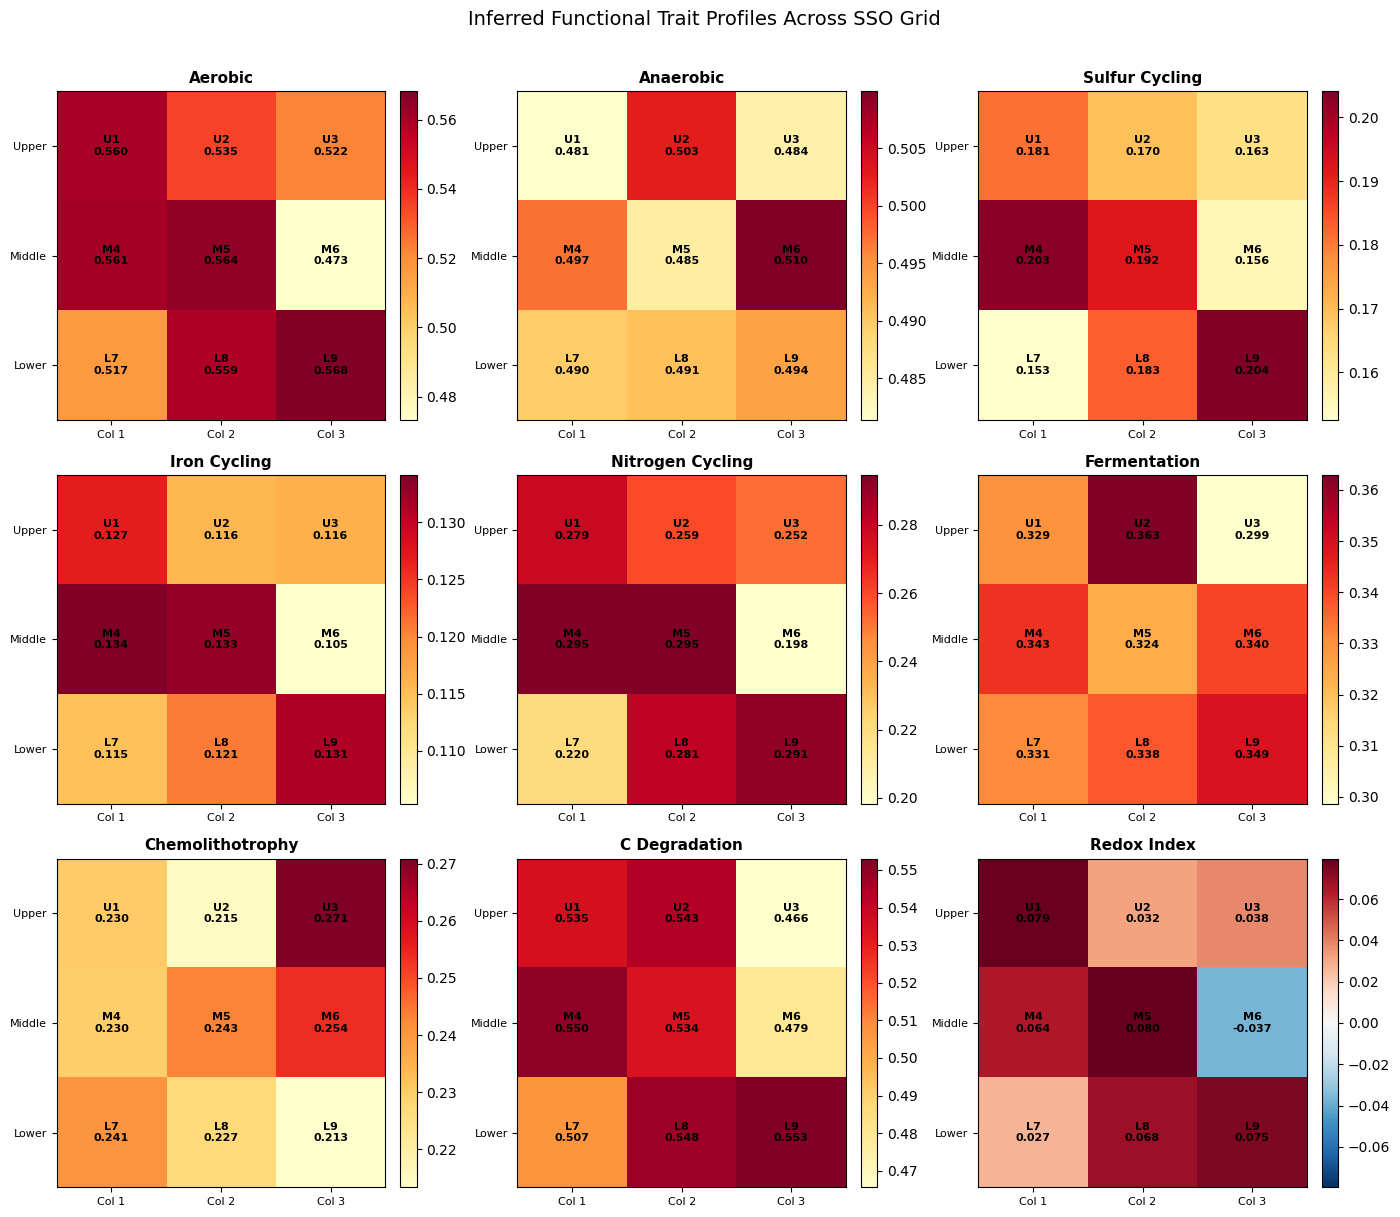

Saved: figures/trait_grid_maps.png


In [5]:
# Plot each trait as a heatmap on the 3x3 grid
traits_to_plot = TRAIT_NAMES + ['redox_index']
n_traits = len(traits_to_plot)
ncols = 3
nrows = (n_traits + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes = axes.flatten()

for idx, trait in enumerate(traits_to_plot):
    ax = axes[idx]
    
    # Build 3x3 grid array
    grid = np.full((3, 3), np.nan)
    for well in WELL_ORDER:
        r, c = GRID[well]
        grid[2-r, c] = trait_profiles.loc[well, trait]  # flip row for display
    
    vmin, vmax = grid[~np.isnan(grid)].min(), grid[~np.isnan(grid)].max()
    
    # Choose colormap: diverging for redox_index, sequential for others
    cmap = 'RdBu_r' if 'redox' in trait else 'YlOrRd'
    center = 0 if 'redox' in trait else None
    
    im = ax.imshow(grid, cmap=cmap, vmin=vmin if center is None else -max(abs(vmin), abs(vmax)),
                   vmax=vmax if center is None else max(abs(vmin), abs(vmax)),
                   aspect='equal', interpolation='nearest')
    
    # Annotate with values and well names
    for well in WELL_ORDER:
        r, c = GRID[well]
        val = trait_profiles.loc[well, trait]
        ax.text(c, 2-r, f"{well.replace('SSO-','')}\n{val:.3f}", 
                ha='center', va='center', fontsize=8, fontweight='bold')
    
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Col 1', 'Col 2', 'Col 3'], fontsize=8)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Upper', 'Middle', 'Lower'], fontsize=8)
    ax.set_title(trait.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Hide empty axes
for idx in range(len(traits_to_plot), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Inferred Functional Trait Profiles Across SSO Grid', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'trait_grid_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/trait_grid_maps.png")

## 4. Spatial Gradient Tests

For each trait, test whether it correlates with grid position (row = uphill/downhill, column = east/west) or with community-based spatial axes identified in NB02.

In [6]:
# Test trait correlations with grid position
rows = np.array([GRID[w][0] for w in WELL_ORDER])  # 0=Lower, 2=Upper
cols = np.array([GRID[w][1] for w in WELL_ORDER])  # 0=Col1, 2=Col3

# Also test diagonal (Col3 corridor from NB02: U3-M6-L7)
# Diagonal score: higher for wells along the U3-M6-L7 corridor
diag_score = np.array([cols[i] - rows[i] for i in range(9)])  # positive = eastern lower

gradient_results = []
all_traits = TRAIT_NAMES + ['redox_index']

for trait in all_traits:
    vals = trait_profiles.loc[WELL_ORDER, trait].values.astype(float)
    
    rho_row, p_row = spearmanr(rows, vals)
    rho_col, p_col = spearmanr(cols, vals)
    rho_diag, p_diag = spearmanr(diag_score, vals)
    
    gradient_results.append({
        'trait': trait,
        'rho_row': round(rho_row, 3), 'p_row': round(p_row, 4),
        'rho_col': round(rho_col, 3), 'p_col': round(p_col, 4),
        'rho_diag': round(rho_diag, 3), 'p_diag': round(p_diag, 4),
    })

grad_df = pd.DataFrame(gradient_results)
grad_df.to_csv(DATA / 'trait_spatial_gradients.csv', index=False)

print("Spatial gradient tests for each trait:")
print(f"{'Trait':<22} {'Row(ρ)':>7} {'Row(p)':>7} {'Col(ρ)':>7} {'Col(p)':>7} {'Diag(ρ)':>8} {'Diag(p)':>8}")
print("-" * 70)
for _, r in grad_df.iterrows():
    sig_r = "*" if r['p_row'] < 0.05 else " "
    sig_c = "*" if r['p_col'] < 0.05 else " "
    sig_d = "*" if r['p_diag'] < 0.05 else " "
    print(f"{r['trait']:<22} {r['rho_row']:>+7.3f}{sig_r} {r['p_row']:>6.3f} "
          f"{r['rho_col']:>+7.3f}{sig_c} {r['p_col']:>6.3f} "
          f"{r['rho_diag']:>+8.3f}{sig_d} {r['p_diag']:>7.3f}")

print("\n* = p < 0.05")
print("\nRow: + = increases uphill; Col: + = increases eastward")
print("Diag: + = increases toward eastern/lower corner (Col3 corridor direction)")

Spatial gradient tests for each trait:
Trait                   Row(ρ)  Row(p)  Col(ρ)  Col(p)  Diag(ρ)  Diag(p)
----------------------------------------------------------------------
aerobic                 -0.158   0.684  -0.105   0.787   -0.009    0.983
anaerobic               -0.211   0.586  +0.264   0.493   +0.299    0.434
sulfur_cycling          -0.211   0.586  +0.000   1.000   +0.103    0.793
iron_cycling            -0.053   0.893  -0.264   0.493   -0.188    0.628
nitrogen_cycling        -0.158   0.684  -0.211   0.586   -0.077    0.844
fermentation            -0.211   0.586  +0.053   0.893   +0.128    0.742
chemolithotrophy        +0.316   0.407  +0.158   0.684   -0.060    0.878
C_degradation           -0.369   0.329  -0.211   0.586   +0.060    0.878
redox_index             +0.000   1.000  -0.158   0.684   -0.111    0.776

* = p < 0.05

Row: + = increases uphill; Col: + = increases eastward
Diag: + = increases toward eastern/lower corner (Col3 corridor direction)


## 5. Functional Heatmap Across Wells

Visualize all traits across all wells as a clustered heatmap. This reveals whether wells cluster by functional profile in a way that matches the spatial or community patterns from NB02.

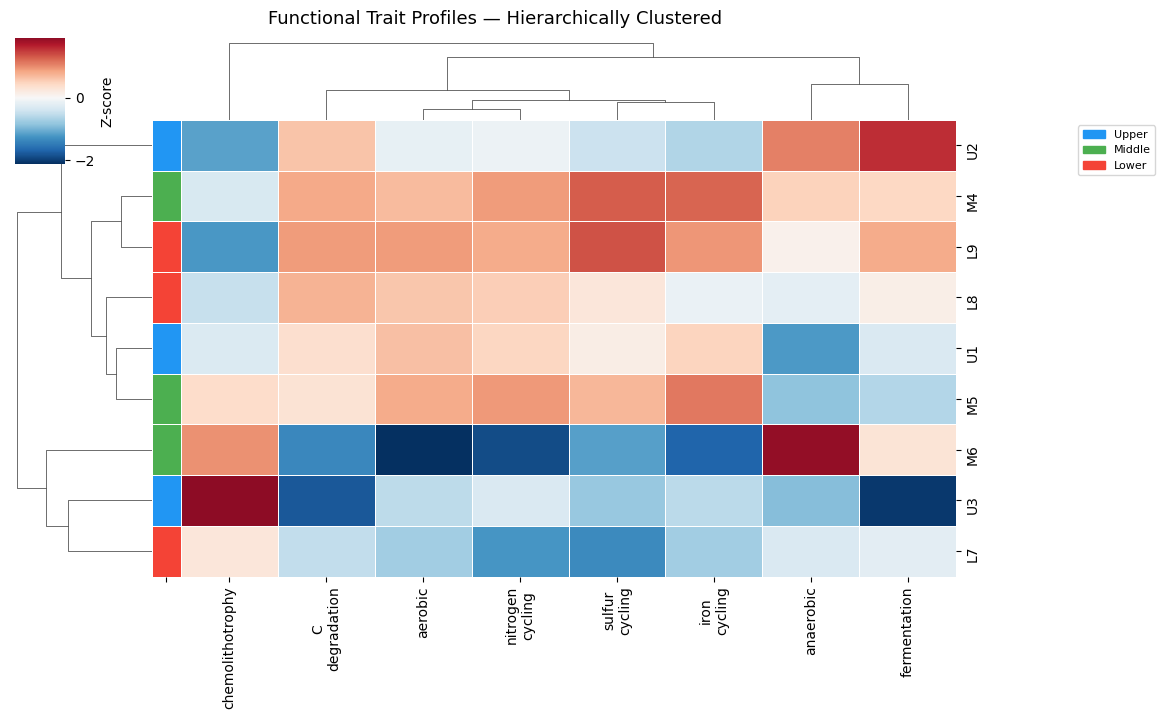

Saved: figures/trait_clustermap.png


In [7]:
# Clustered heatmap of trait profiles
plot_traits = trait_profiles[TRAIT_NAMES].copy()

# Z-score across wells for each trait (to show relative enrichment)
plot_z = plot_traits.subtract(plot_traits.mean()).div(plot_traits.std())

# Row colors for well grouping
row_colors_map = {w: {'U': '#2196F3', 'M': '#4CAF50', 'L': '#F44336'}[w[4]] for w in WELL_ORDER}
row_colors = pd.Series(row_colors_map)

g = sns.clustermap(plot_z, cmap='RdBu_r', center=0, 
                   row_colors=row_colors,
                   figsize=(10, 7), linewidths=0.5,
                   dendrogram_ratio=(0.15, 0.15),
                   cbar_kws={'label': 'Z-score'},
                   yticklabels=[w.replace('SSO-', '') for w in WELL_ORDER],
                   xticklabels=[t.replace('_', '\n') for t in TRAIT_NAMES])
g.fig.suptitle('Functional Trait Profiles — Hierarchically Clustered', fontsize=13, y=1.02)

# Add legend for row colors
handles = [mpatches.Patch(color='#2196F3', label='Upper'),
           mpatches.Patch(color='#4CAF50', label='Middle'),
           mpatches.Patch(color='#F44336', label='Lower')]
g.ax_heatmap.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.15, 1), fontsize=8)

plt.savefig(FIG / 'trait_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/trait_clustermap.png")

## 6. Environmental Interpretation

Synthesize the functional gradient patterns with the spatial and depth findings from NB02 and NB03 to infer likely environmental gradients across the SSO grid.

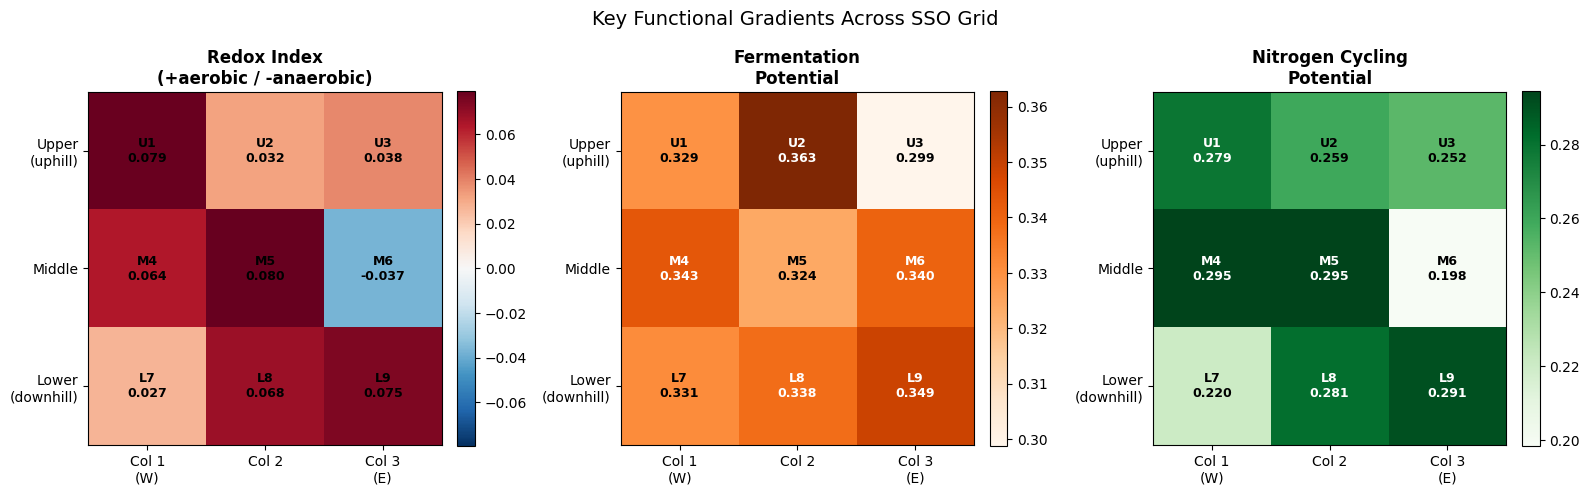

Saved: figures/key_functional_gradients.png


In [8]:
# Focused plot: redox index and fermentation on grid (key environmental indicators)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

focus_traits = [('redox_index', 'RdBu_r', 'Redox Index\n(+aerobic / -anaerobic)'),
                ('fermentation', 'Oranges', 'Fermentation\nPotential'),
                ('nitrogen_cycling', 'Greens', 'Nitrogen Cycling\nPotential')]

for ax, (trait, cmap, title) in zip(axes, focus_traits):
    grid = np.full((3, 3), np.nan)
    for well in WELL_ORDER:
        r, c = GRID[well]
        grid[2-r, c] = trait_profiles.loc[well, trait]
    
    vals = grid[~np.isnan(grid)]
    if 'redox' in trait:
        vlim = max(abs(vals.min()), abs(vals.max()))
        im = ax.imshow(grid, cmap=cmap, vmin=-vlim, vmax=vlim, aspect='equal')
    else:
        im = ax.imshow(grid, cmap=cmap, vmin=vals.min(), vmax=vals.max(), aspect='equal')
    
    for well in WELL_ORDER:
        r, c = GRID[well]
        val = trait_profiles.loc[well, trait]
        ax.text(c, 2-r, f"{well.replace('SSO-','')}\n{val:.3f}",
                ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if val > vals.mean() and 'redox' not in trait else 'black')
    
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['Col 1\n(W)', 'Col 2', 'Col 3\n(E)'])
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(['Upper\n(uphill)', 'Middle', 'Lower\n(downhill)'])
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Key Functional Gradients Across SSO Grid', fontsize=14)
plt.tight_layout()
plt.savefig(FIG / 'key_functional_gradients.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/key_functional_gradients.png")

## 7. Summary

In [9]:
print("=" * 60)
print("NB04 FUNCTIONAL INFERENCE SUMMARY")
print("=" * 60)

print(f"\n1. TRAIT COVERAGE")
print(f"   {len(mapped_phyla)} phyla mapped / {len(phylum_rel.columns)} total")
print(f"   Mean coverage: {coverage.mean()*100:.1f}% of reads assigned traits")

print(f"\n2. SPATIAL GRADIENT TESTS")
sig_traits = grad_df[(grad_df['p_row'] < 0.1) | (grad_df['p_col'] < 0.1) | (grad_df['p_diag'] < 0.1)]
if len(sig_traits) > 0:
    print(f"   Traits with suggestive spatial gradients (p < 0.1):")
    for _, r in sig_traits.iterrows():
        axes = []
        if r['p_row'] < 0.1:
            dir_r = "uphill" if r['rho_row'] > 0 else "downhill"
            axes.append(f"row({dir_r}, ρ={r['rho_row']:+.3f}, p={r['p_row']:.3f})")
        if r['p_col'] < 0.1:
            dir_c = "eastward" if r['rho_col'] > 0 else "westward"
            axes.append(f"col({dir_c}, ρ={r['rho_col']:+.3f}, p={r['p_col']:.3f})")
        if r['p_diag'] < 0.1:
            axes.append(f"diag(ρ={r['rho_diag']:+.3f}, p={r['p_diag']:.3f})")
        print(f"   {r['trait']:<22} {'; '.join(axes)}")
else:
    print("   No traits reach p < 0.1 for spatial gradients")
    print("   (expected with n=9 wells — see trait grid maps for visual patterns)")

print(f"\n3. TRAIT RANGE ACROSS WELLS")
for trait in TRAIT_NAMES:
    vals = trait_profiles[trait].astype(float)
    cv = vals.std() / vals.mean() * 100 if vals.mean() > 0 else 0
    print(f"   {trait:<22} {vals.min():.3f} - {vals.max():.3f} (CV={cv:.1f}%)")

print(f"\n4. ENVIRONMENTAL INFERENCE")
print(f"   Redox index range: {trait_profiles['redox_index'].min():.3f} to {trait_profiles['redox_index'].max():.3f}")
most_aerobic = trait_profiles['redox_index'].idxmax()
most_anaerobic = trait_profiles['redox_index'].idxmin()
print(f"   Most aerobic well:   {most_aerobic} (redox = {trait_profiles.loc[most_aerobic, 'redox_index']:.3f})")
print(f"   Most anaerobic well: {most_anaerobic} (redox = {trait_profiles.loc[most_anaerobic, 'redox_index']:.3f})")

print(f"\nFiles saved:")
print(f"  data/trait_profiles.csv")
print(f"  data/trait_spatial_gradients.csv")
print(f"  figures/trait_grid_maps.png")
print(f"  figures/trait_clustermap.png")
print(f"  figures/key_functional_gradients.png")

NB04 FUNCTIONAL INFERENCE SUMMARY

1. TRAIT COVERAGE
   19 phyla mapped / 85 total
   Mean coverage: 91.5% of reads assigned traits

2. SPATIAL GRADIENT TESTS
   No traits reach p < 0.1 for spatial gradients
   (expected with n=9 wells — see trait grid maps for visual patterns)

3. TRAIT RANGE ACROSS WELLS
   aerobic                0.473 - 0.568 (CV=5.8%)
   anaerobic              0.481 - 0.510 (CV=1.9%)
   sulfur_cycling         0.153 - 0.204 (CV=10.8%)
   iron_cycling           0.105 - 0.134 (CV=8.1%)
   nitrogen_cycling       0.198 - 0.295 (CV=13.1%)
   fermentation           0.299 - 0.363 (CV=5.3%)
   chemolithotrophy       0.213 - 0.271 (CV=7.8%)
   C_degradation          0.466 - 0.553 (CV=6.2%)

4. ENVIRONMENTAL INFERENCE
   Redox index range: -0.037 to 0.080
   Most aerobic well:   SSO-M5 (redox = 0.080)
   Most anaerobic well: SSO-M6 (redox = -0.037)

Files saved:
  data/trait_profiles.csv
  data/trait_spatial_gradients.csv
  figures/trait_grid_maps.png
  figures/trait_clusterm